In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado\DPD"
file_path    = project_path + r"\Optuna_studies"

sys.path.append(project_path)
sys.path.append(file_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from dpd.optuna_tasks import get_pareto

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

In [5]:
EVM_ARVTDNN = np.loadtxt(file_path + f'\\DPD_ARVTDNN\\ILA\\Study_12\\Results\\EVM.txt')
EVM_RVTDNN  = np.loadtxt(file_path + f'\\DPD_RVTDNN\\ILA\\Study_3\\Results\\EVM.txt')
EVM_ETDNN   = np.loadtxt(file_path + f'\\DPD_ETDNN\\ILA\\Study_2\\Results\\EVM.txt')
EVM_KAN     = np.loadtxt(file_path + f'\\DPD_KAN\\ILA\\Study_2\\Results\\EVM.txt')
EVM_EKAN    = np.loadtxt(file_path + f'\\DPD_EKAN\\ILA\\Study_1\\Results\\EVM.txt')
EVM_MP      = np.loadtxt(file_path + f'\\DPD_MP\\ILA\\Study_2\\Results\\EVM.txt')
EVM_CMP     = np.loadtxt(file_path + f'\\DPD_CMP\\ILA\\Study_2\\Results\\EVM.txt')

ACLR_ARVTDNN = np.array([ np.loadtxt(file_path + f"\\DPD_ARVTDNN\\ILA\\Study_12\\Models\\metrics_{i+1}.txt")[1] for i in range(EVM_ARVTDNN.size) ])
ACLR_RVTDNN  = np.array([ np.loadtxt(file_path + f"\\DPD_RVTDNN\\ILA\\Study_3\\Models\\metrics_{i+1}.txt")[1] for i in range(EVM_RVTDNN.size) ])
ACLR_ETDNN   = np.array([ np.loadtxt(file_path + f"\\DPD_ETDNN\\ILA\\Study_2\\Models\\metrics_{i+1}.txt")[1] for i in range(EVM_ETDNN.size) ])
ACLR_KAN     = np.array([ np.loadtxt(file_path + f"\\DPD_KAN\\ILA\\Study_2\\Models\\metrics_{i+1}.txt")[1] for i in range(EVM_KAN.size) ])
ACLR_EKAN    = np.array([ np.loadtxt(file_path + f"\\DPD_EKAN\\ILA\\Study_1\\Models\\metrics_{i+1}.txt")[1] for i in range(EVM_EKAN.size) ])
ACLR_MP      = np.array([ np.loadtxt(file_path + f"\\DPD_MP\\ILA\\Study_2\\Models\\metrics_{i+1}.txt")[1] for i in range(EVM_MP.size) ])
ACLR_CMP     = np.array([ np.loadtxt(file_path + f"\\DPD_CMP\\ILA\\Study_2\\Models\\metrics_{i+1}.txt")[1] for i in range(EVM_CMP.size) ])

NFLOPs_ARVTDNN = np.loadtxt(file_path + f'\\DPD_ARVTDNN\\ILA\\Study_12\\Results\\NFLOPs.txt')
NFLOPs_RVTDNN  = np.loadtxt(file_path + f'\\DPD_RVTDNN\\ILA\\Study_3\\Results\\NFLOPs.txt')
NFLOPs_ETDNN   = np.loadtxt(file_path + f'\\DPD_ETDNN\\ILA\\Study_2\\Results\\NFLOPs.txt')
NFLOPs_KAN    = np.loadtxt(file_path + f'\\DPD_KAN\\ILA\\Study_2\\Results\\NFLOPs.txt')
NFLOPs_EKAN    = np.loadtxt(file_path + f'\\DPD_EKAN\\ILA\\Study_1\\Results\\NFLOPs.txt')
NFLOPs_MP      = np.loadtxt(file_path + f'\\DPD_MP\\ILA\\Study_2\\Results\\NFLOPs.txt')
NFLOPs_CMP     = np.loadtxt(file_path + f'\\DPD_CMP\\ILA\\Study_2\\Results\\NFLOPs.txt')

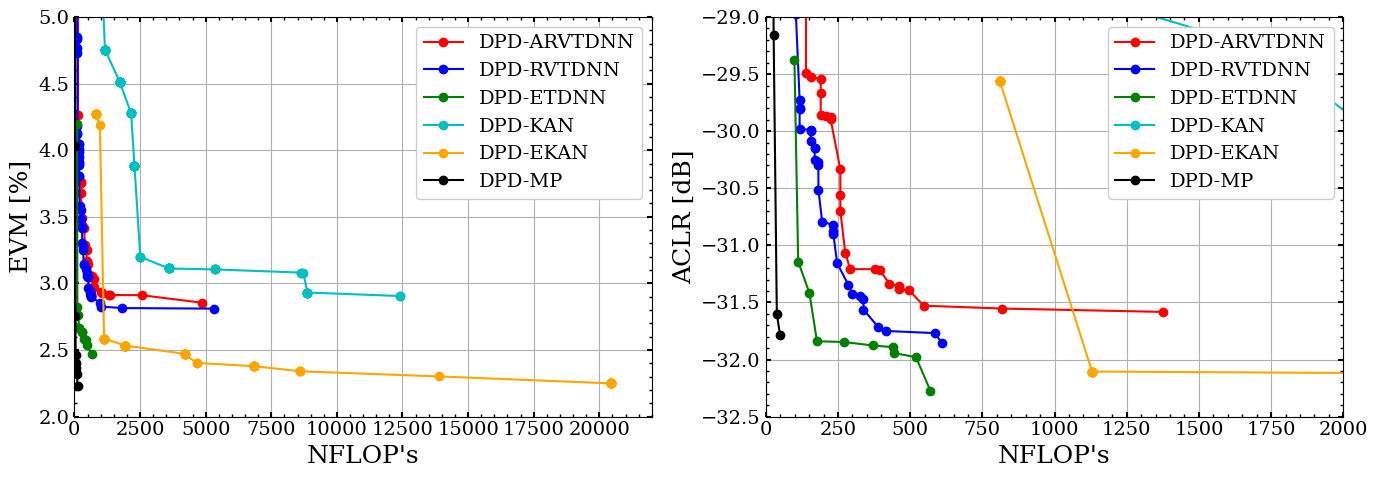

In [6]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

dpd_type    = ["ARVTDNN", "RVTDNN", "ETDNN", "KAN", "EKAN", "MP", "CMP"]
evm_list    = [EVM_ARVTDNN, EVM_RVTDNN, EVM_ETDNN, EVM_KAN, EVM_EKAN, EVM_MP, EVM_CMP]
aclr_list   = [ACLR_ARVTDNN, ACLR_RVTDNN, ACLR_ETDNN, ACLR_KAN, ACLR_EKAN, ACLR_MP, ACLR_CMP]
nflops_list = [NFLOPs_ARVTDNN, NFLOPs_RVTDNN, NFLOPs_ETDNN, NFLOPs_KAN, NFLOPs_EKAN, NFLOPs_MP, NFLOPs_CMP]
color_list  = ["r", "b", "g", "c", "orange", "k", "pink"]

for i in range(6):
    # EVM vs NFLOPs
    pareto_solutions_evm, pareto_trials_evm = get_pareto(evm_list[i], nflops_list[i], evm_list[i].size)
    pareto_solutions_aclr, pareto_trials_aclr = get_pareto(aclr_list[i], nflops_list[i], aclr_list[i].size)
    
    axs[0].plot(pareto_solutions_evm[:,1], pareto_solutions_evm[:,0], "-o", color = color_list[i], label = f"DPD-{dpd_type[i]}")
    axs[1].plot(pareto_solutions_aclr[:,1], pareto_solutions_aclr[:,0], "-o", color = color_list[i], label = f"DPD-{dpd_type[i]}")
    
axs[0].set_xlim(0, 22e3)
axs[0].set_ylim(2., 5)
axs[0].set_xlabel("NFLOP's", fontsize = 18)
axs[0].set_ylabel("EVM [%]", fontsize = 18)

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()
axs[0].legend(framealpha = 1, loc = "upper right", fontsize = 14)

axs[1].set_xlim(0, 2e3)
axs[1].set_ylim(-32.5, -29)
axs[1].set_xlabel("NFLOP's", fontsize = 18)
axs[1].set_ylabel("ACLR [dB]", fontsize = 18)

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()
axs[1].legend(framealpha = 1, loc = "upper right", fontsize = 14)

plt.tight_layout()
#plt.savefig(file_path + "\\Plots\\plot_pareto_EVM.png")